In [ ]:
import itertools

import transformers
import torch
import plotly.express
import plotly.graph_objects
import sklearn.decomposition
import PIL.Image
import numpy as np
import matplotlib
from torch import Tensor

In [ ]:
device = "cuda"
model_ckpt = "meta-llama/Llama-3.2-1B"

### Preliminaries

In [ ]:
model = transformers.AutoModel.from_pretrained(model_ckpt).eval()
tokenizer = transformers.AutoTokenizer.from_pretrained(model_ckpt)
model = model.half().to(device).eval()

In [ ]:
def sinusoidal_encode(
    x: Tensor,
    embedding_dim: int,
    min_value: int,
    max_value: int,
    use_l2_norm: bool = False,
    norm_const: float | None = None,
) -> Tensor:
    """
    Encodes a tensor of numbers into a sinusoidal representation, inspired by how absolute positional
    encoding works in transformers.

    The encoding is an evaluation of a sine and cosine function at different frequencies, where the
    frequency is determined by the embedding dimension and the allowed range of the input values.

    >>> sinusoidal_encode(
    ...     torch.tensor([-5, 2, 1, 0]),
    ...     embedding_dim=6,
    ...     min_value=-5,
    ...     max_value=5,
    ... )
    tensor([[ 0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000],
            [ 0.6570,  0.7539, -0.1073, -0.9942,  0.9980,  0.0627],
            [-0.2794,  0.9602,  0.3491, -0.9371,  0.9616,  0.2746],
            [-0.9589,  0.2837,  0.7317, -0.6816,  0.8806,  0.4738]])
    """

    if embedding_dim % 2 != 0 and not use_l2_norm:
        raise ValueError("Embedding dimension must be even")

    if use_l2_norm:
        if embedding_dim % 2 == 0:
            reserved_dim = 2
        else:
            reserved_dim = 1
        embedding_dim -= reserved_dim
    else:
        reserved_dim = 0  # will not be used

    domain = max_value - min_value
    y_shape = x.shape + (embedding_dim,)
    y = torch.zeros(y_shape, device=x.device)
    even_indices = torch.arange(0, embedding_dim, 2)
    log_term = torch.log(torch.tensor(domain)) / embedding_dim
    div_term = torch.exp(even_indices * -log_term)
    x = x - min_value
    values = x.unsqueeze(-1).float() * div_term
    y[..., 0::2] = torch.sin(values)
    y[..., 1::2] = torch.cos(values)

    if use_l2_norm:
        y = torch.cat([y, torch.ones_like(y[..., :reserved_dim])], dim=-1)
        y /= y.norm(dim=-1, keepdim=True, p=2)

    if norm_const is not None:
        y *= norm_const

    return y

In [5]:
all_values = torch.arange(0, 1000)
all_tokens = tokenizer([str(x) for x in all_values.tolist()], return_tensors="pt", add_special_tokens=False).input_ids.flatten()
mask = torch.rand(len(all_values), generator=torch.Generator().manual_seed(0))
train_mask = mask < 0.9
valid_mask = ~train_mask & (mask < 0.95)
test_mask = ~train_mask & ~valid_mask

train_values = all_values[train_mask]
valid_values = all_values[valid_mask]
test_values = all_values[test_mask]

train_tokens = all_tokens[train_mask]
valid_tokens = all_tokens[valid_mask]
test_tokens = all_tokens[test_mask]

# shuffle train_values and train_tokens the same way
train_shuffle = torch.randperm(len(train_values))
train_values = train_values[train_shuffle]
train_tokens = train_tokens[train_shuffle]

In [6]:
class ClassifierProbe(torch.nn.Module):
    def __init__(self, emb_dim: int, hidden_dim: int, basis: torch.Tensor, heldout_mask: torch.Tensor):
        super().__init__()
        self.emb_to_latent = torch.nn.Linear(emb_dim, hidden_dim, bias=True)
        self.basis_to_latent = torch.nn.Linear(basis.shape[-1], hidden_dim, bias=True)
        self.basis: torch.nn.Buffer
        self.heldout_mask: torch.nn.Buffer
        self.register_buffer("basis", basis)
        self.register_buffer("heldout_mask", heldout_mask)
        
    def forward(self, x: Tensor, holdout_eval_tokens: bool) -> Tensor:
        latent_x = self.emb_to_latent(x)
        # during training, model learns to choose among only training tokens
        # but during eval, model must choose among all tokens
        # this means that the model is never exposed to the eval tokens during training
        latent_choices = self.basis_to_latent(self.basis)
        logits = latent_x @ latent_choices.T
        if holdout_eval_tokens:
            logits[:, self.heldout_mask] = float("-inf")
        return logits

### Fit Probes

In [7]:
basis_embs = sinusoidal_encode(
    torch.arange(0, 1000),
    embedding_dim=model.config.hidden_size,
    min_value=0,
    max_value=999,
).to(device)

probes = {"l1": [], "l2": []}

for regularization in ["l1", "l2"]:

    for repetition in range(3):
        print(f"REGULARIZATION: {regularization} REPETITION: {repetition}")
        torch.manual_seed(repetition)

        probe = ClassifierProbe(
            emb_dim=model.config.hidden_size,
            hidden_dim=100,
            basis=basis_embs,
            heldout_mask=~train_mask,
        ).to(device)

        if regularization == "l2":
            optimizer = torch.optim.Adam(probe.parameters(), lr=1e-4, weight_decay=1e-3)
        else:
            optimizer = torch.optim.Adam(probe.parameters(), lr=1e-4)

        best_valid_loss = float('inf')
        best_ckpt = probe.state_dict()

        for epoch in range(20000+1):
            probe.train()
            optimizer.zero_grad()
            train_x = model.embed_tokens(train_tokens.to(device))
            train_y = train_values.to(device)
            logits = probe(train_x.float(), holdout_eval_tokens=True)
            loss = torch.nn.functional.cross_entropy(logits, train_y)
            if regularization == "l1":
                loss += 0.001 * sum(p.abs().sum() for p in probe.parameters())
            loss.backward()
            optimizer.step()
            if epoch % 1000 == 0:
                probe.eval()
                with torch.no_grad():
                    valid_x = model.embed_tokens(valid_tokens.to(device))
                    valid_y = valid_values.to(device)
                    logits = probe(valid_x.float(), holdout_eval_tokens=False)
                    acc = (logits.argmax(dim=-1) == valid_y).float().mean()
                    valid_loss = torch.nn.functional.cross_entropy(logits, valid_y)
                    if valid_loss < best_valid_loss:
                        best_valid_loss = valid_loss
                        best_ckpt = probe.state_dict()
                    print(f"  Epoch {epoch}, Loss: {loss.item():.2f}, Valid Acc: {acc.item():.2%}")
                    
        probe.load_state_dict(best_ckpt)
        test_x = model.embed_tokens(test_tokens.to(device))
        test_y = test_values.to(device)
        logits = probe(test_x.float(), holdout_eval_tokens=False)
        acc = (logits.argmax(dim=-1) == test_y).float().mean()
        print(f"  -> repetition {repetition}, Test Acc: {acc.item():.2%}")
        probes[regularization].append(probe)

REGULARIZATION: l1 REPETITION: 0
  Epoch 0, Loss: 11.33, Valid Acc: 0.00%
  Epoch 1000, Loss: 3.89, Valid Acc: 45.61%
  Epoch 2000, Loss: 3.00, Valid Acc: 75.44%
  Epoch 3000, Loss: 2.56, Valid Acc: 87.72%
  Epoch 4000, Loss: 2.33, Valid Acc: 91.23%
  Epoch 5000, Loss: 2.17, Valid Acc: 94.74%
  Epoch 6000, Loss: 2.05, Valid Acc: 92.98%
  Epoch 7000, Loss: 1.95, Valid Acc: 91.23%
  Epoch 8000, Loss: 1.87, Valid Acc: 94.74%
  Epoch 9000, Loss: 1.81, Valid Acc: 94.74%
  Epoch 10000, Loss: 1.75, Valid Acc: 92.98%
  Epoch 11000, Loss: 1.70, Valid Acc: 92.98%
  Epoch 12000, Loss: 1.65, Valid Acc: 92.98%
  Epoch 13000, Loss: 1.62, Valid Acc: 94.74%
  Epoch 14000, Loss: 1.58, Valid Acc: 92.98%
  Epoch 15000, Loss: 1.55, Valid Acc: 89.47%
  Epoch 16000, Loss: 1.53, Valid Acc: 91.23%
  Epoch 17000, Loss: 1.50, Valid Acc: 89.47%
  Epoch 18000, Loss: 1.47, Valid Acc: 89.47%
  Epoch 19000, Loss: 1.45, Valid Acc: 89.47%
  Epoch 20000, Loss: 1.43, Valid Acc: 85.96%
  -> repetition 0, Test Acc: 89.09%

### Visualize probes' pattern

In [ ]:
def pca(embs: Tensor, low_dim: int) -> tuple[Tensor, Tensor]:
    pca = sklearn.decomposition.PCA(n_components=low_dim)
    reduced_embs = pca.fit_transform(embs.detach().numpy())
    return torch.tensor(reduced_embs), torch.tensor(pca.explained_variance_ratio_)

def fourier(embs: Tensor) -> Tensor:
    return torch.fft.fft(embs, dim=0)

def vis_emb(embs: Tensor, colorful: bool) -> plotly.graph_objects.Figure:
    x = embs.cpu().detach()
    x_normalized = (x - x.min()) / (x.max() - x.min())
    theme = matplotlib.colormaps["Blues"]
    if colorful:
        x_normalized = theme(x_normalized)
    else:
        x_normalized = x_normalized.numpy()
    vis = PIL.Image.fromarray((x_normalized * 255).astype(np.uint8))
    return vis

Probe's Pattern (L1)


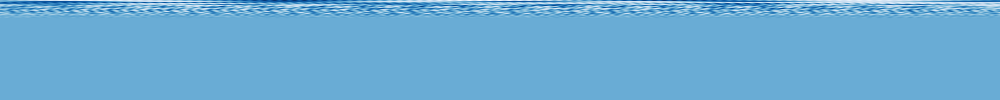

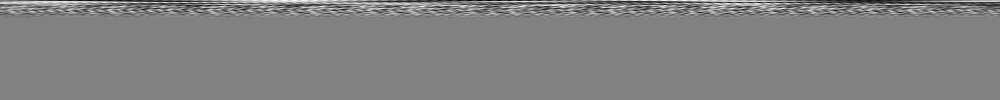

Probe's Pattern (L1)


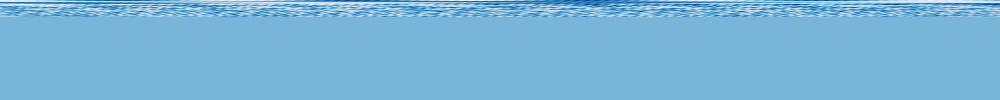

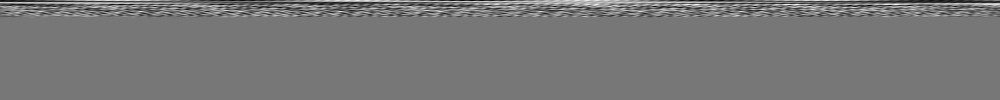

Probe's Pattern (L1)


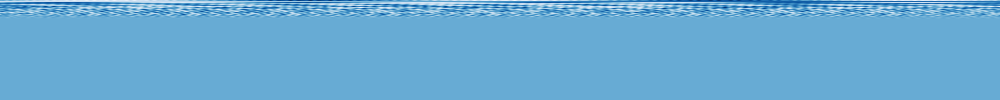

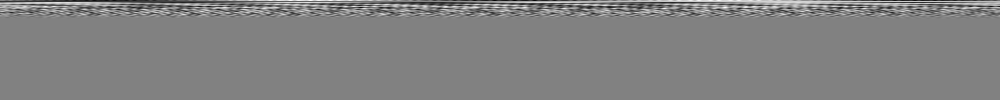

Probe's Pattern (L2)


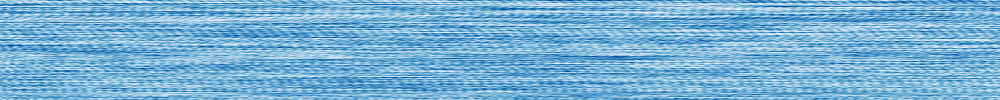

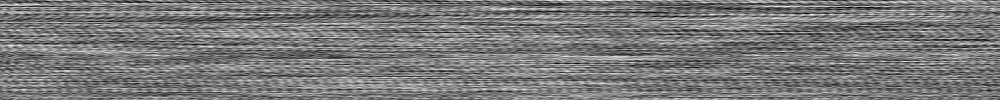

Probe's Pattern (L2)


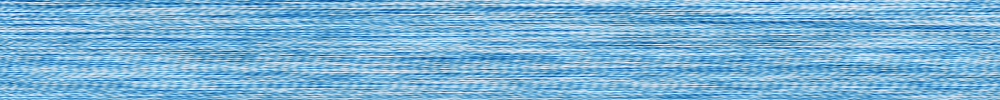

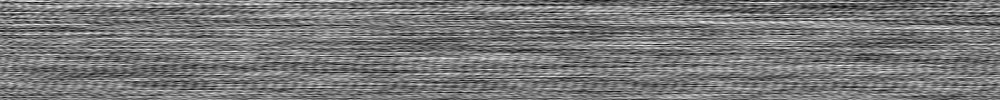

Probe's Pattern (L2)


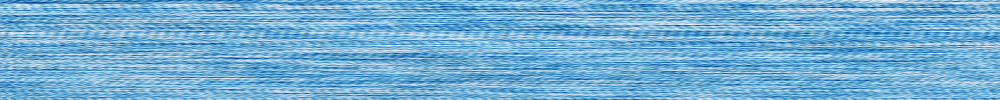

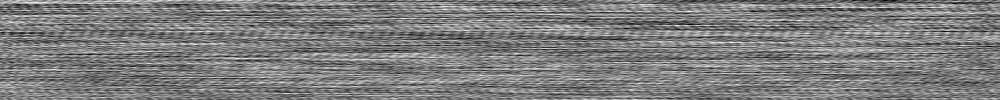

In [53]:
for reg, probes_reg in probes.items():
    for probe in probes_reg:
        latents = probe.basis_to_latent(basis_embs.to(device)).cpu()
        latents = sorted(latents.T, key=lambda x: x.abs().sum(), reverse=True)
        print(f"Probe's Pattern ({reg.upper()})", flush=True)
        display(vis_emb(torch.stack(latents), colorful=True))
        display(vis_emb(torch.stack(latents), colorful=False))

### Visualize Basis probes' weights

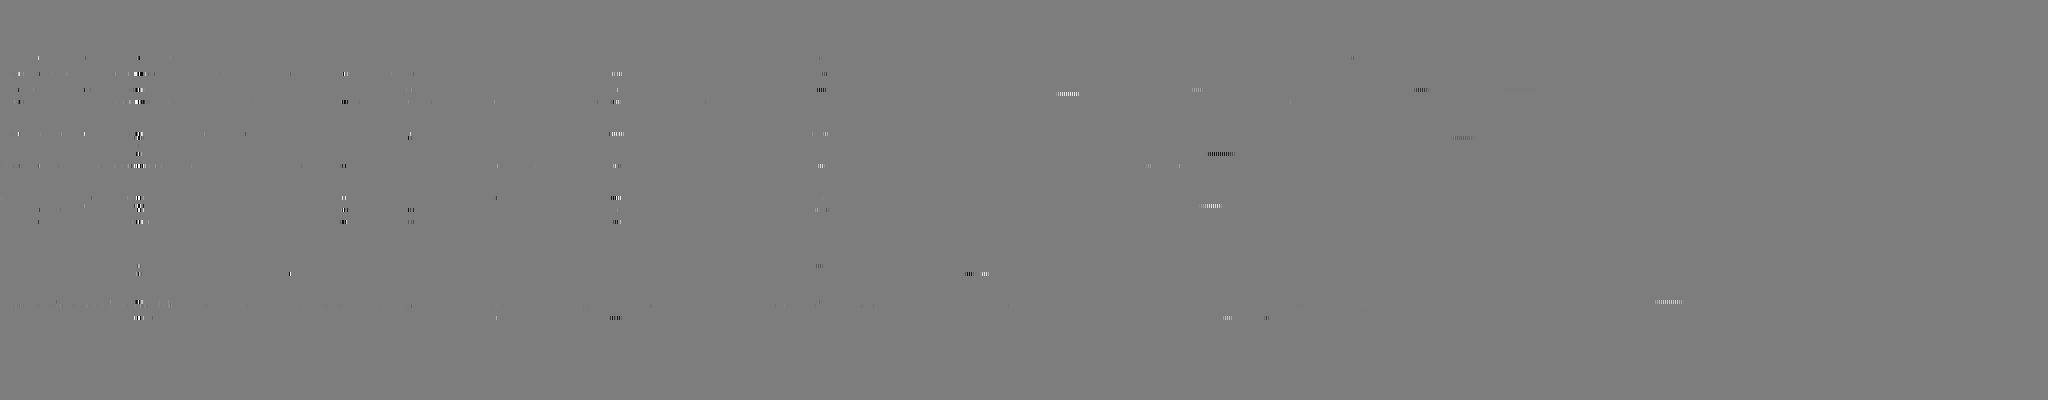

In [81]:
vis = vis_emb(
    probes["l1"][0].basis_to_latent.weight,
    colorful=False
)
vis.resize((vis.width, 400), PIL.Image.Resampling.NEAREST)

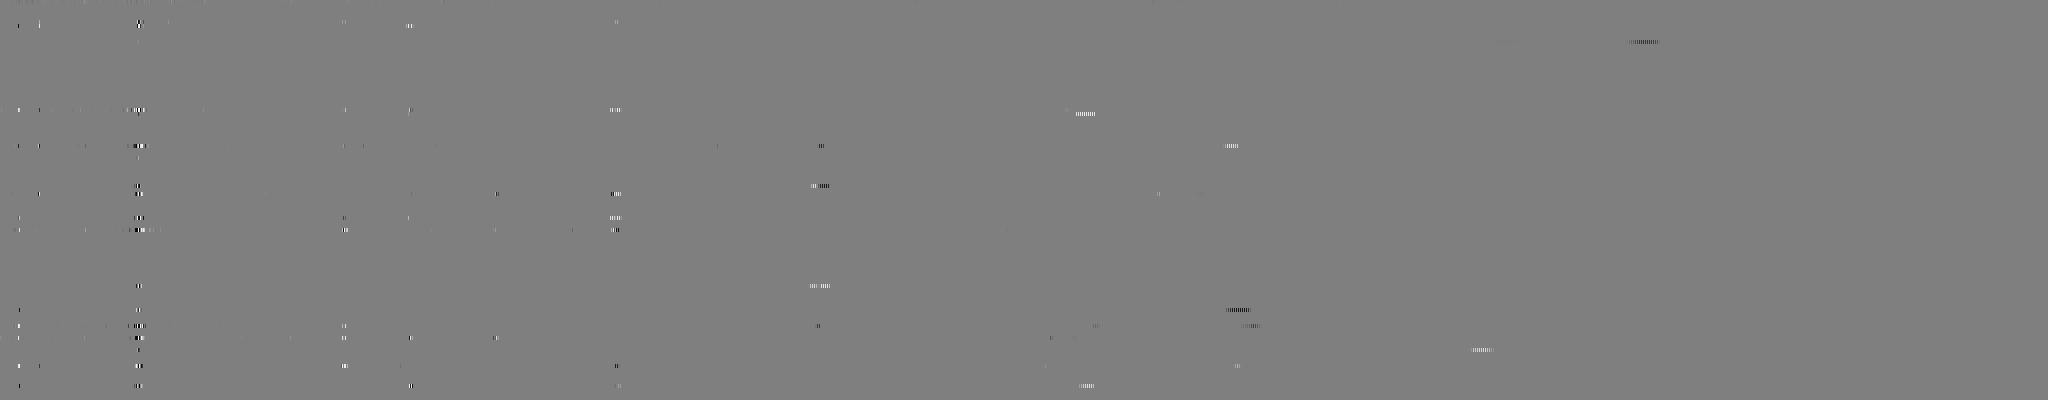

In [82]:
vis = vis_emb(
    probes["l1"][-1].basis_to_latent.weight,
    colorful=False
)
vis.resize((vis.width, 400), PIL.Image.Resampling.NEAREST)

### Comparing frequencies discovered by the probe on multiple fits

x = latent feature y = basis features (sine/cosine waves) 

Attempt 0 - Probe's Weights (reg='l1', threshold=0.1)


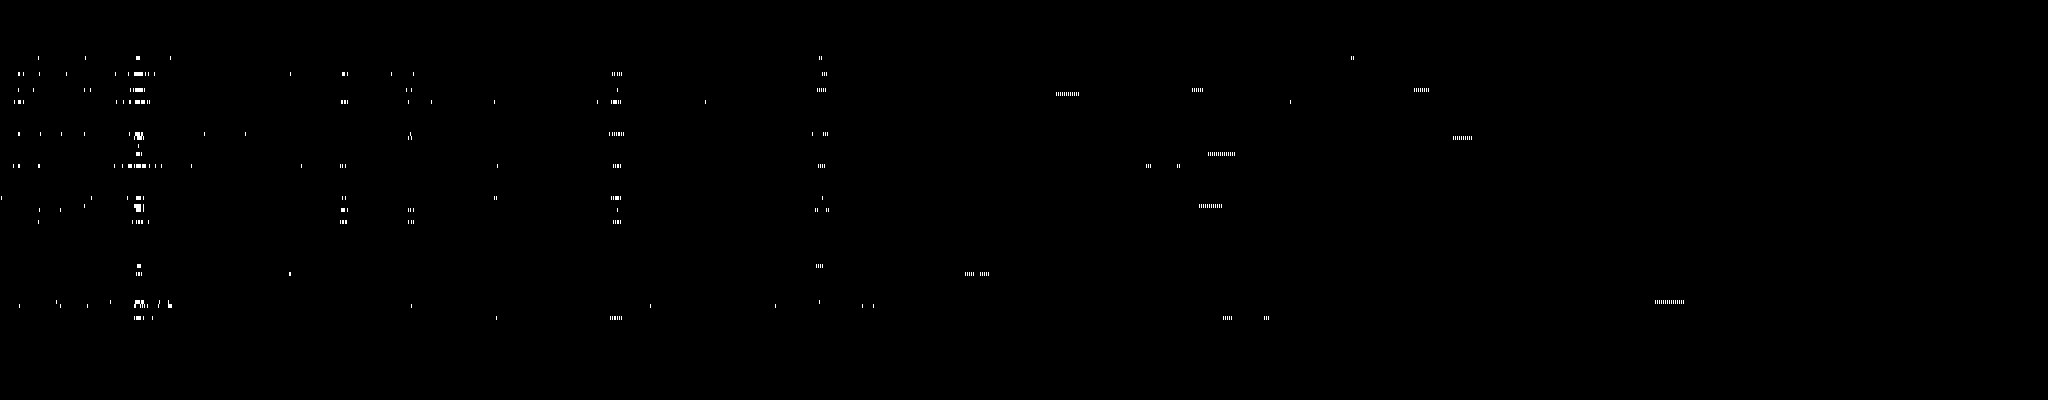

Attempt 1 - Probe's Weights (reg='l1', threshold=0.1)


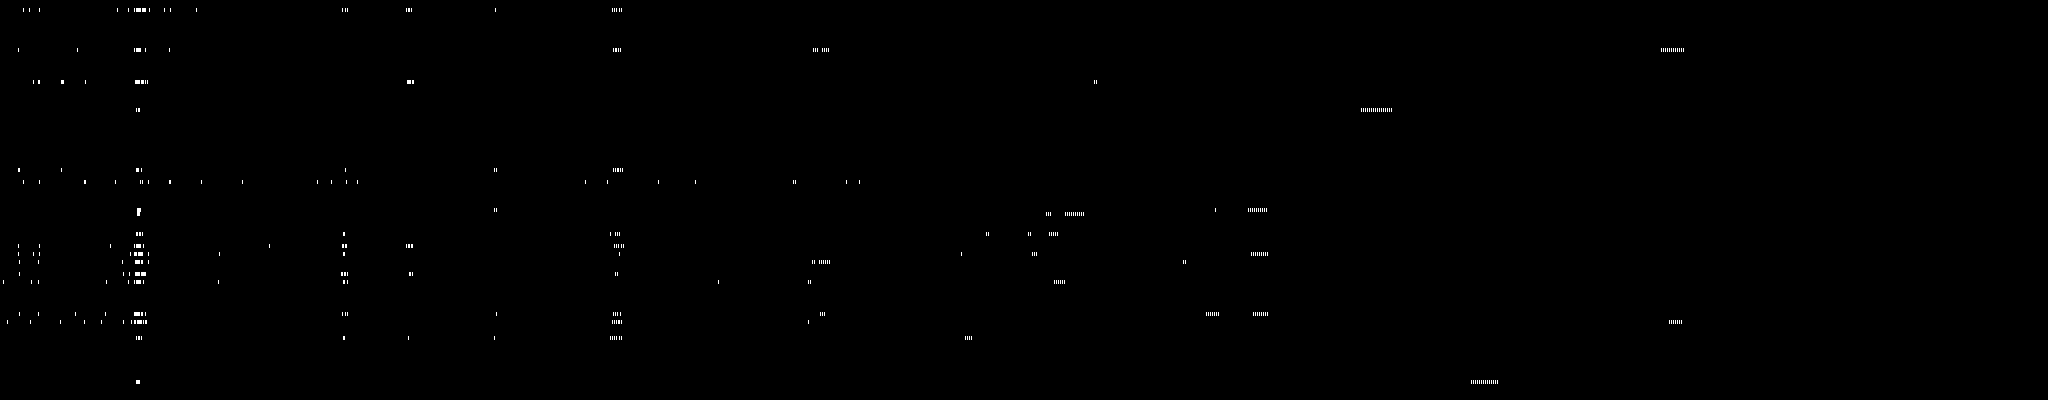

Attempt 2 - Probe's Weights (reg='l1', threshold=0.1)


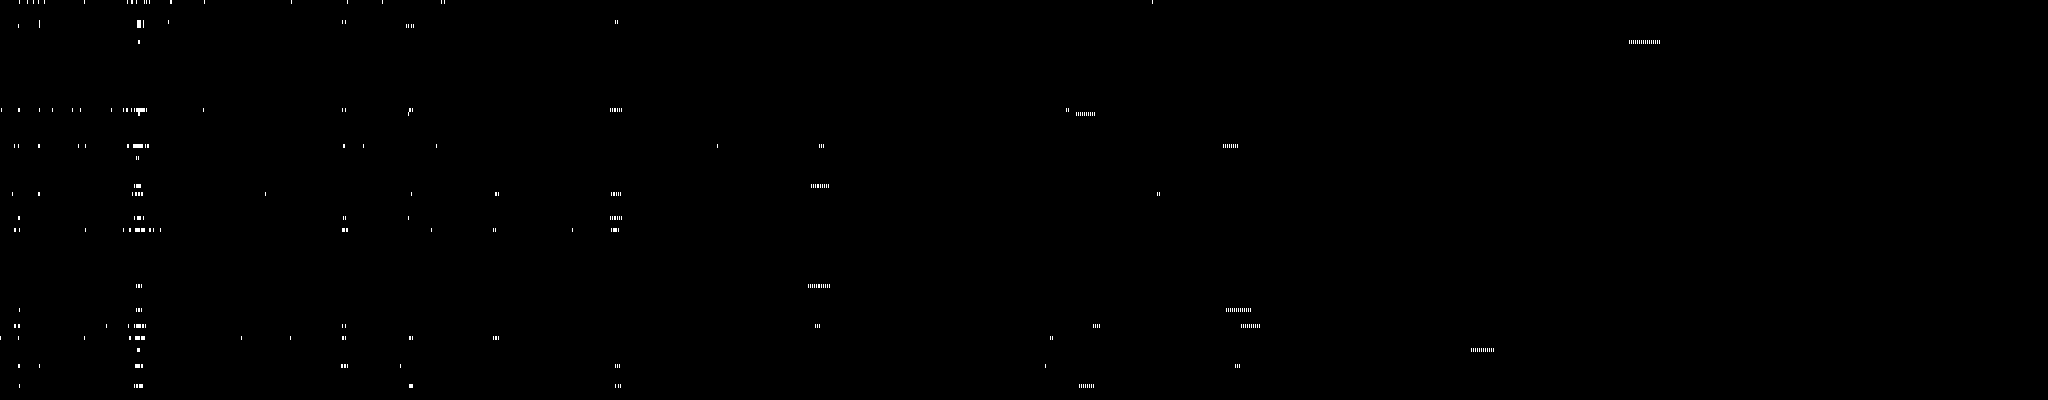

Attempt 0 - Probe's Weights (reg='l1', threshold=0.01)


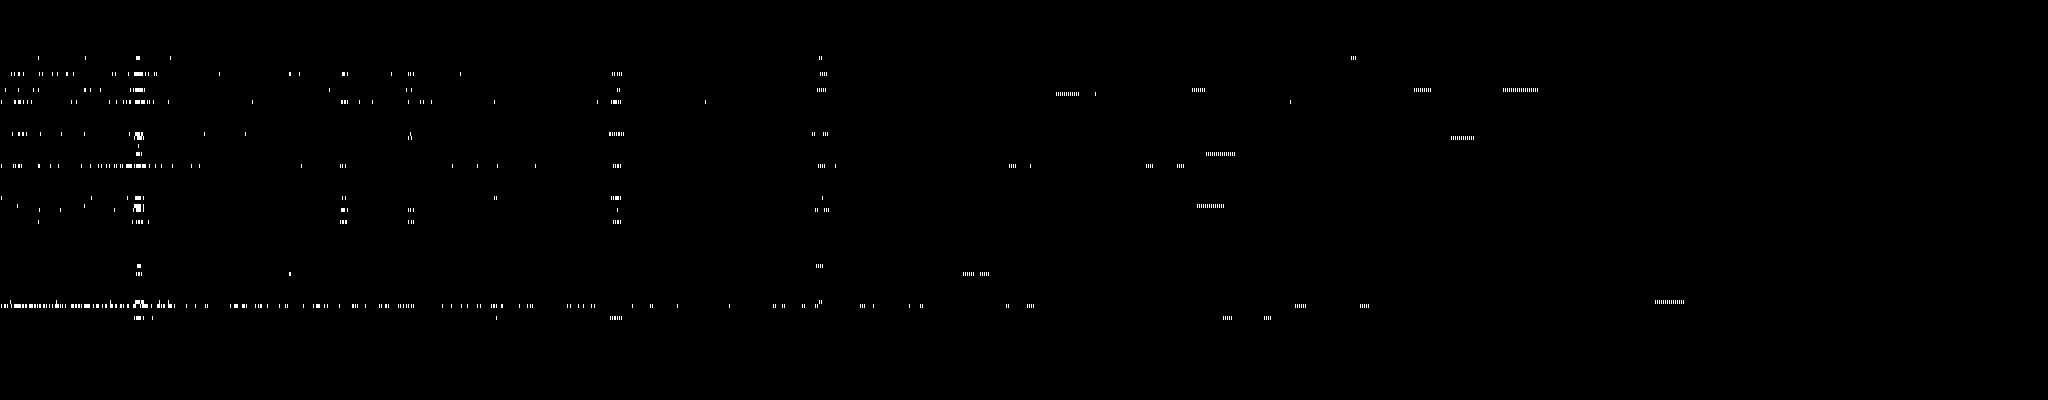

Attempt 1 - Probe's Weights (reg='l1', threshold=0.01)


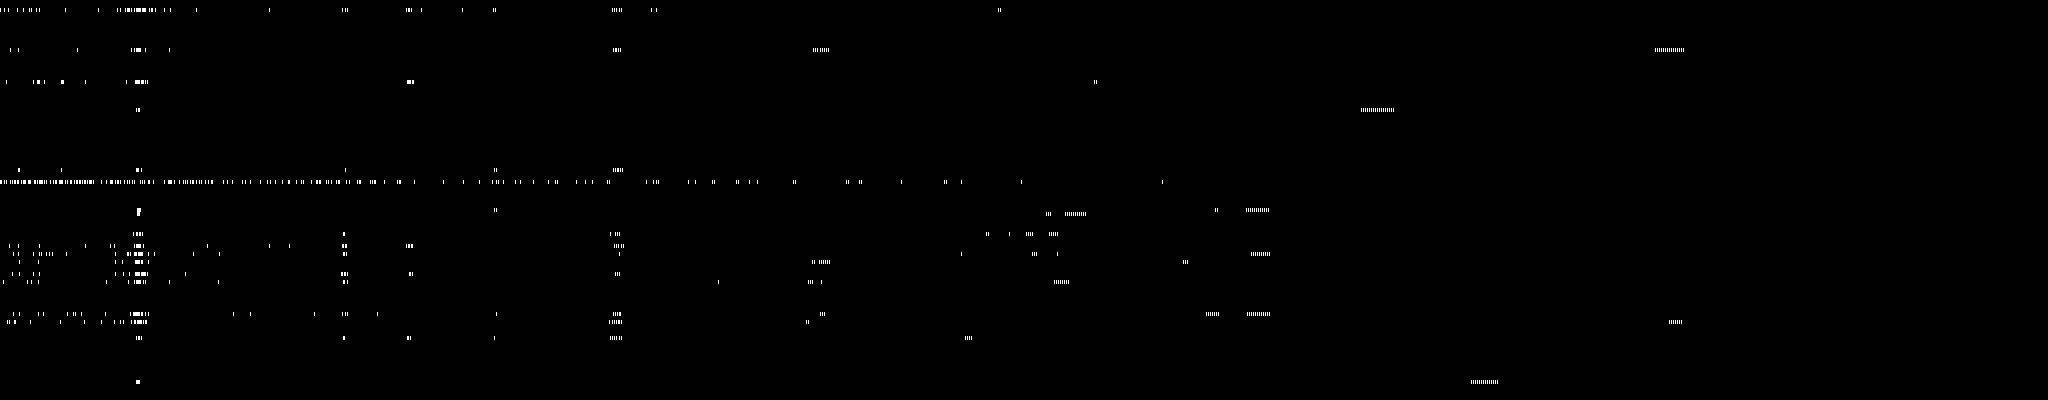

Attempt 2 - Probe's Weights (reg='l1', threshold=0.01)


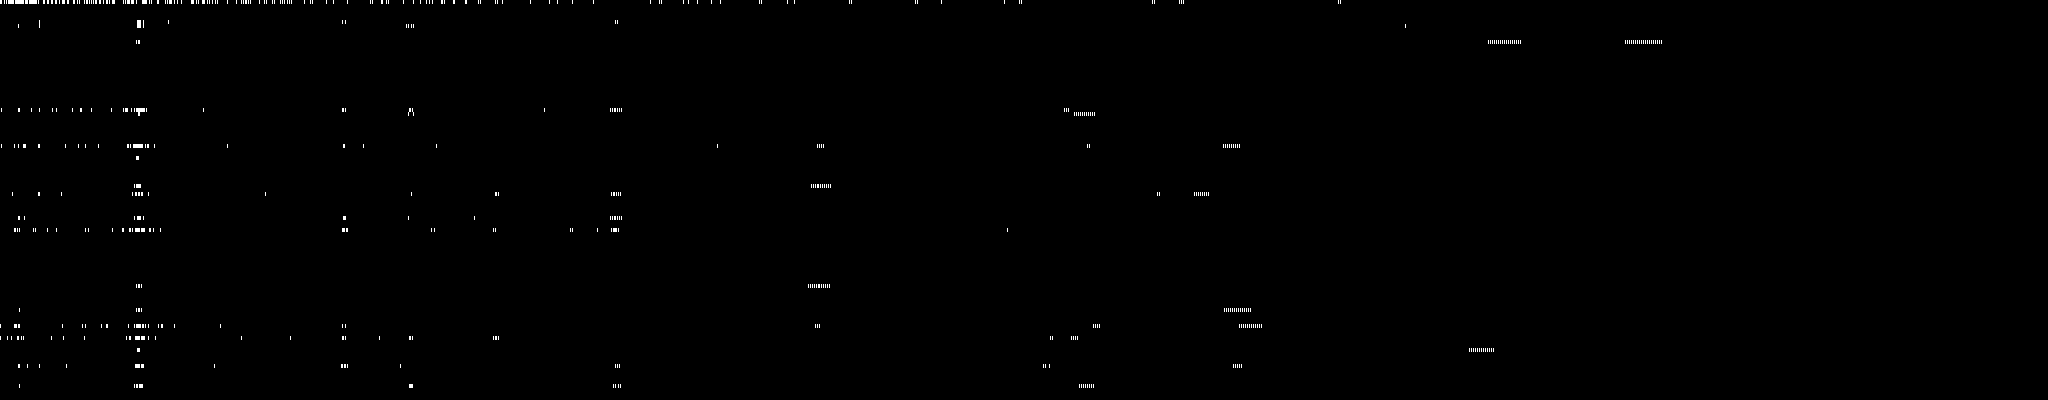

Attempt 0 - Probe's Weights (reg='l1', threshold=0.001)


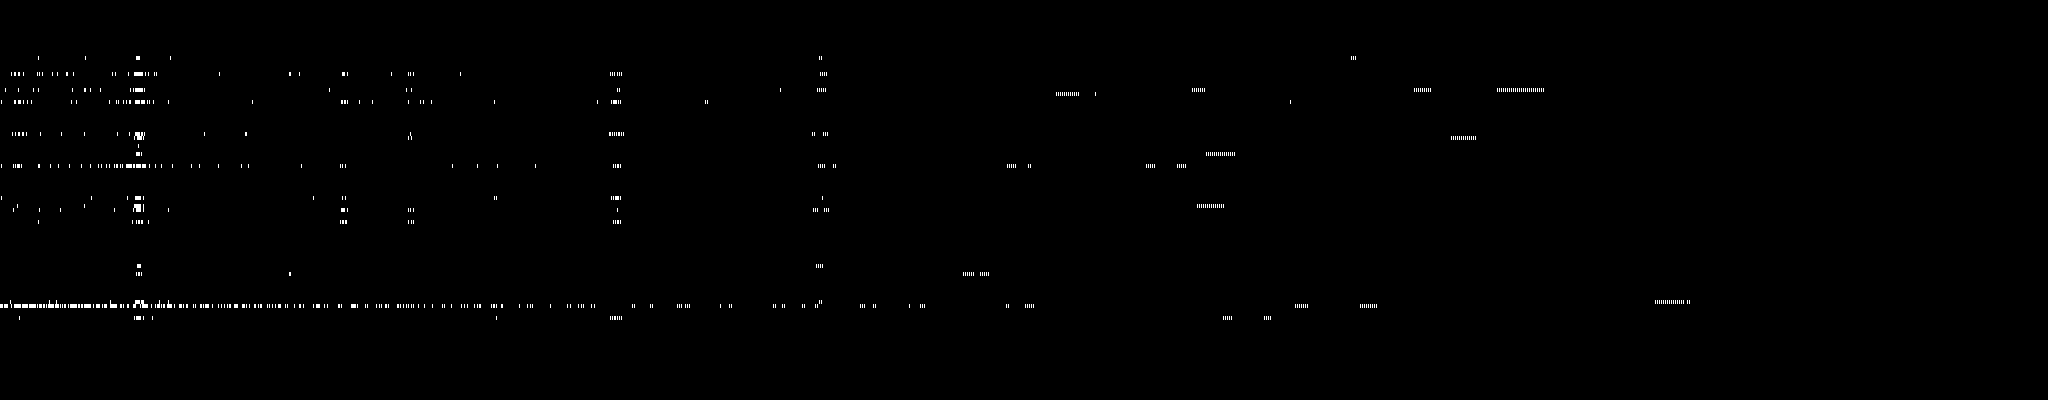

Attempt 1 - Probe's Weights (reg='l1', threshold=0.001)


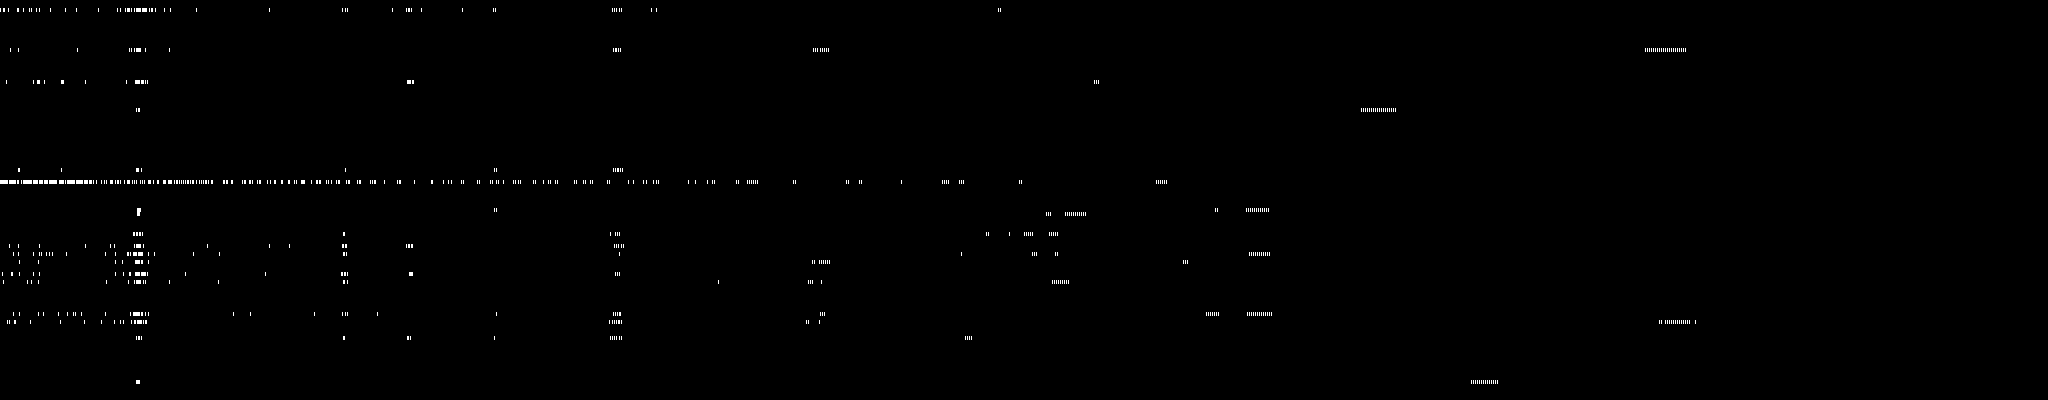

Attempt 2 - Probe's Weights (reg='l1', threshold=0.001)


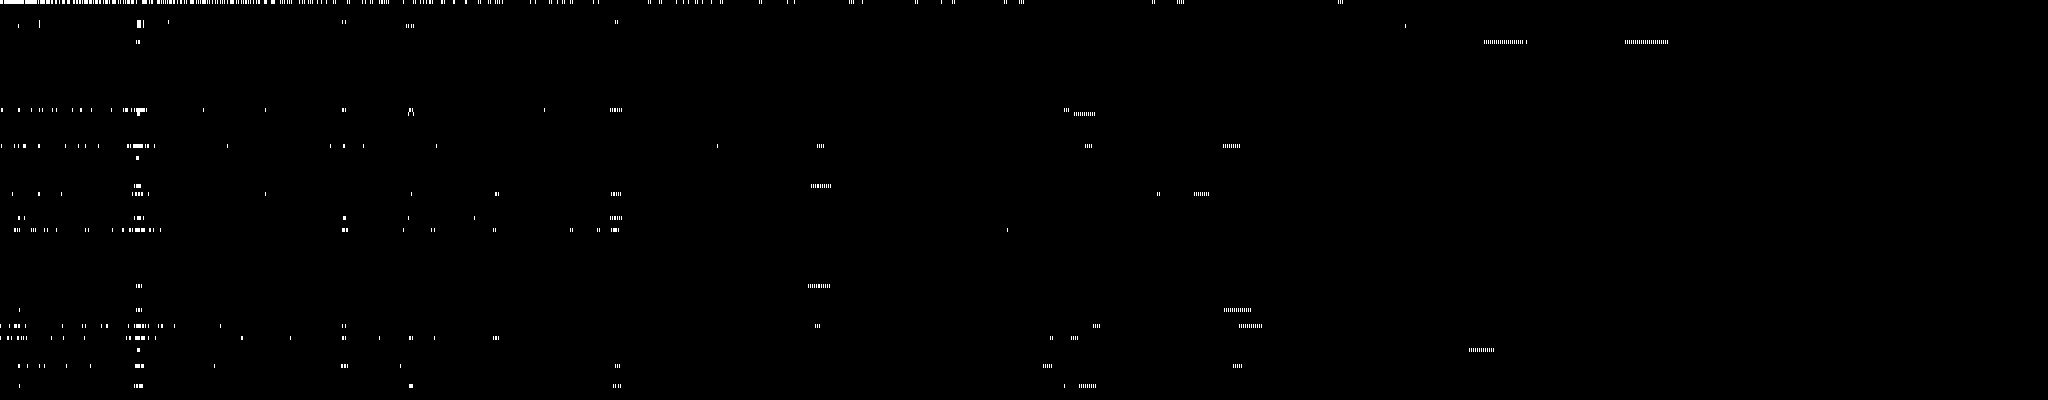

Attempt 0 - Probe's Weights (reg='l2', threshold=0.1)


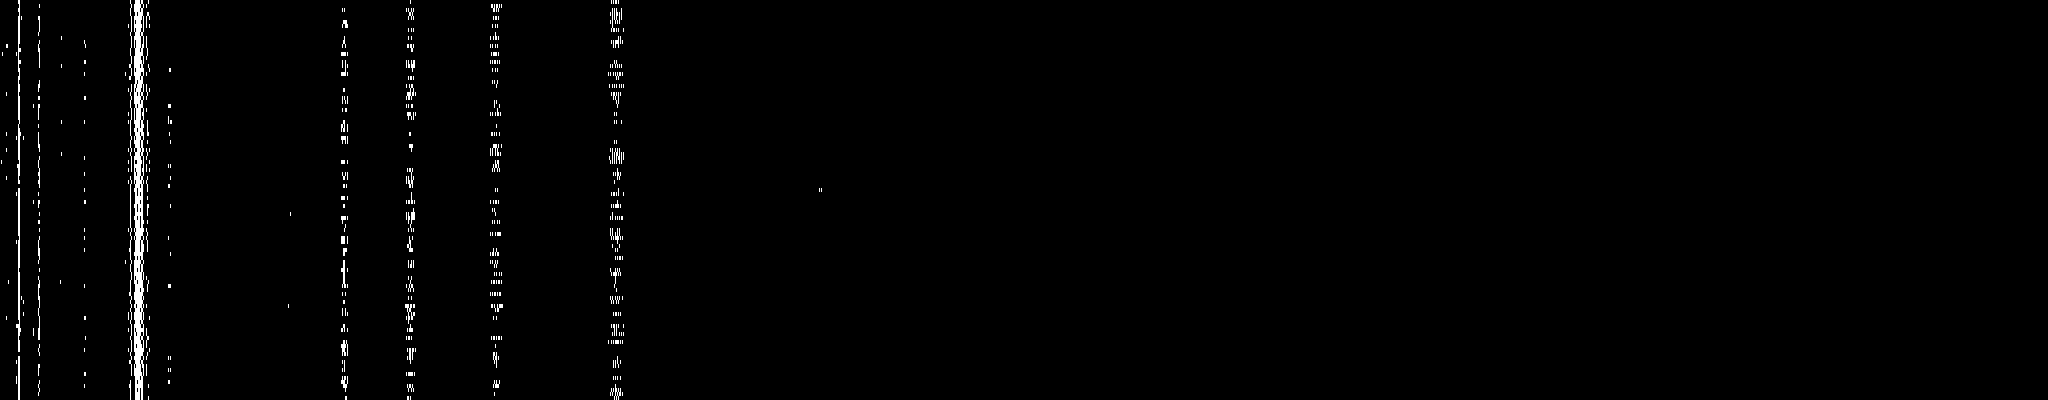

Attempt 1 - Probe's Weights (reg='l2', threshold=0.1)


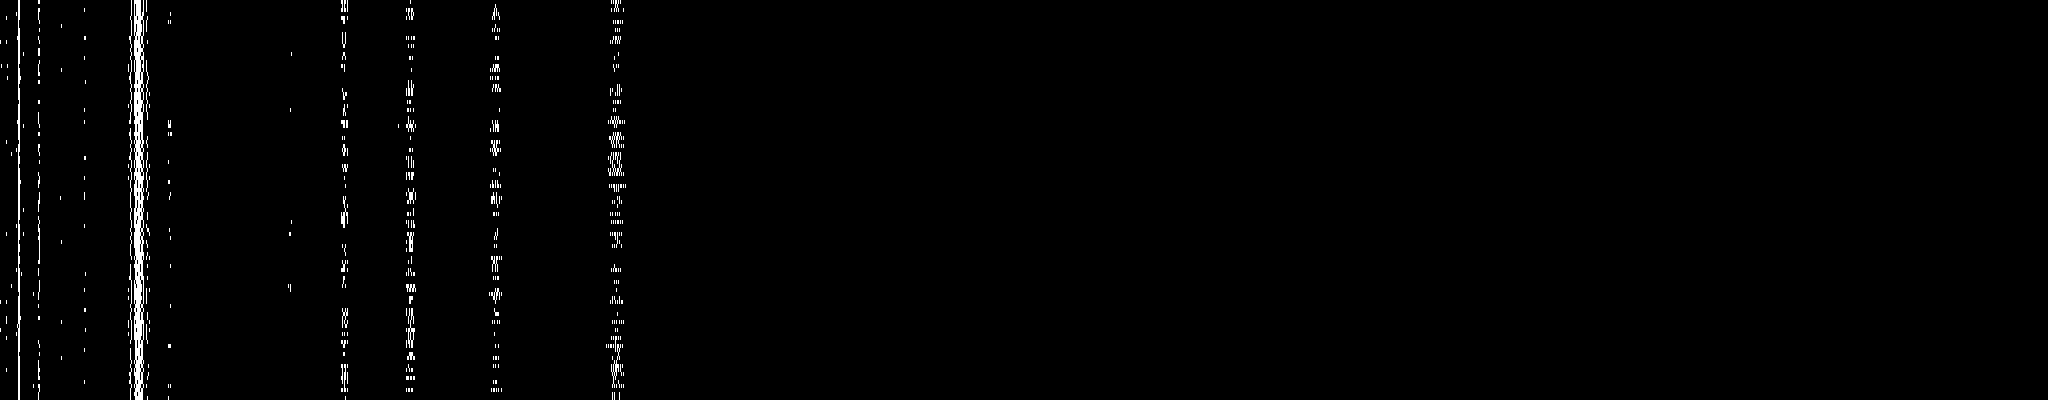

Attempt 2 - Probe's Weights (reg='l2', threshold=0.1)


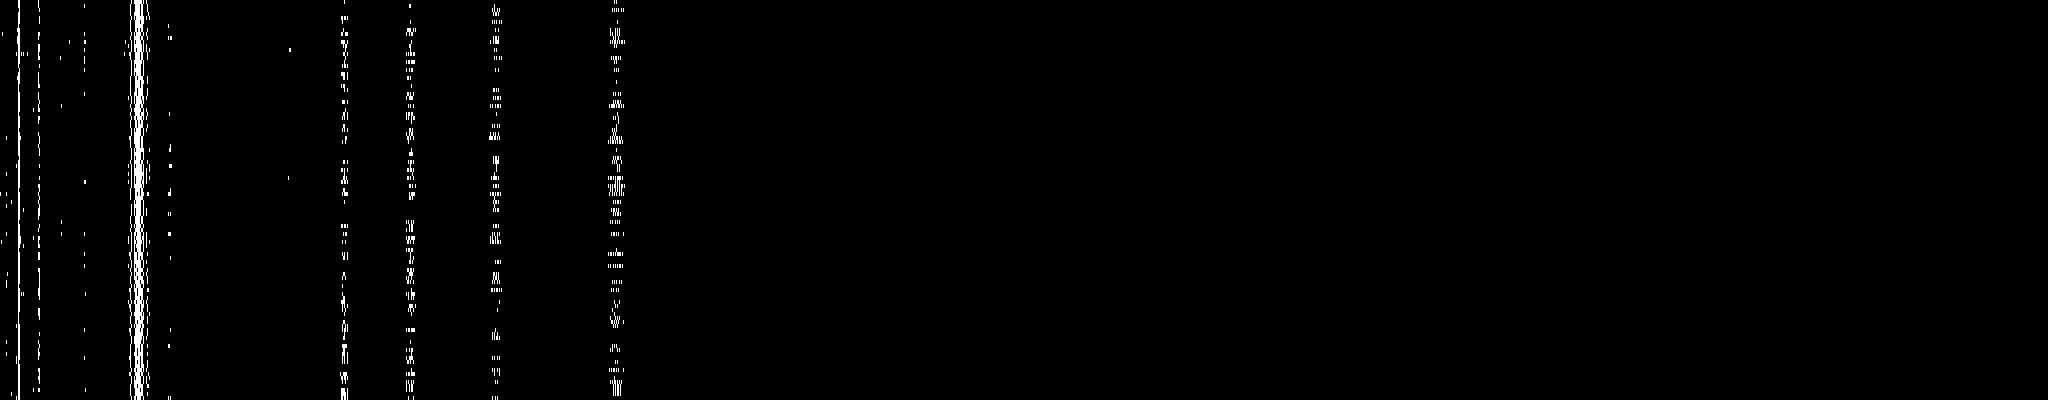

Attempt 0 - Probe's Weights (reg='l2', threshold=0.01)


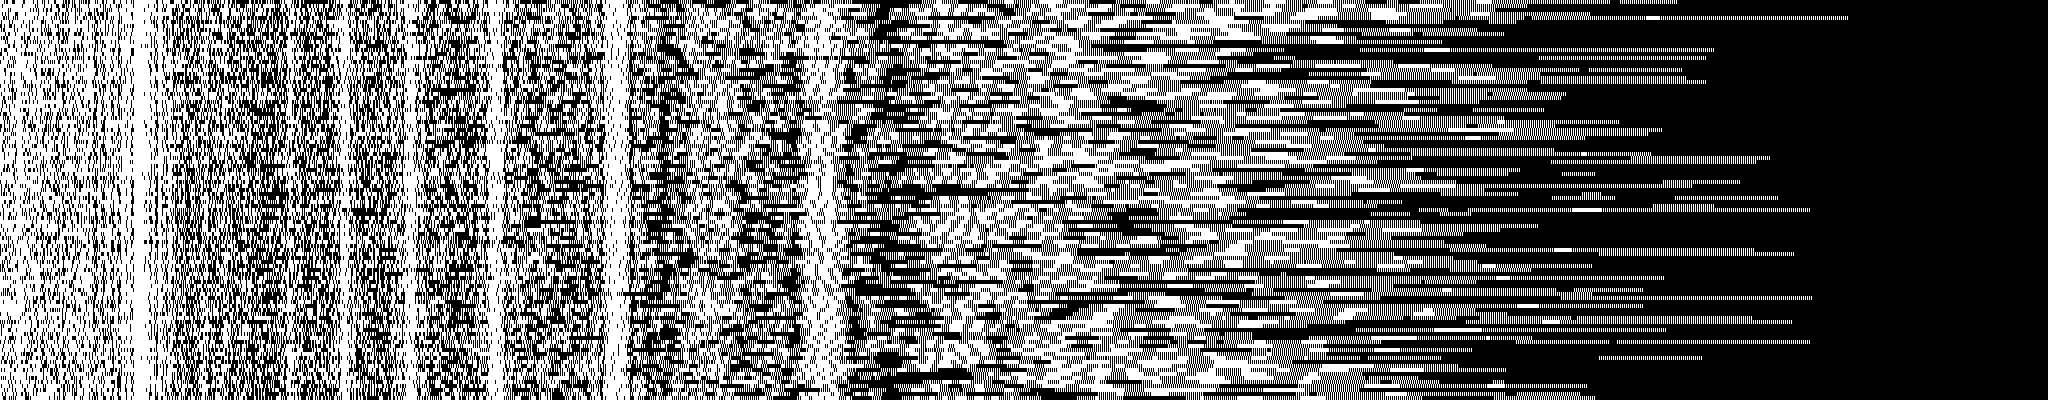

Attempt 1 - Probe's Weights (reg='l2', threshold=0.01)


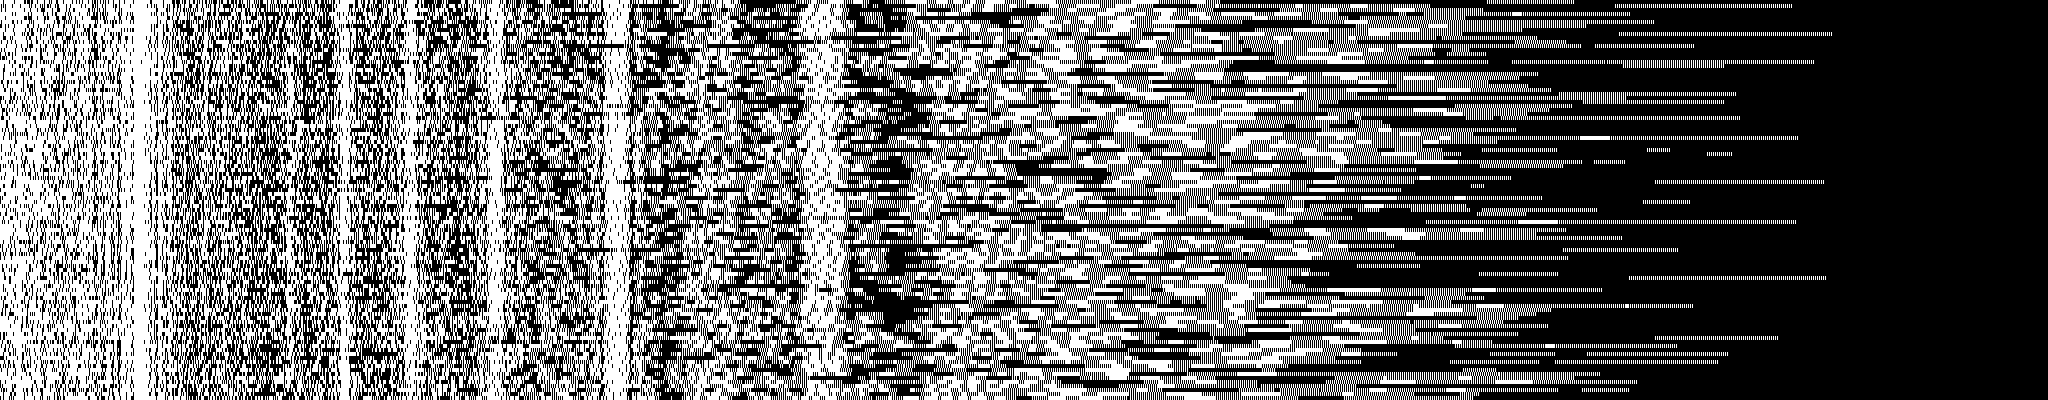

Attempt 2 - Probe's Weights (reg='l2', threshold=0.01)


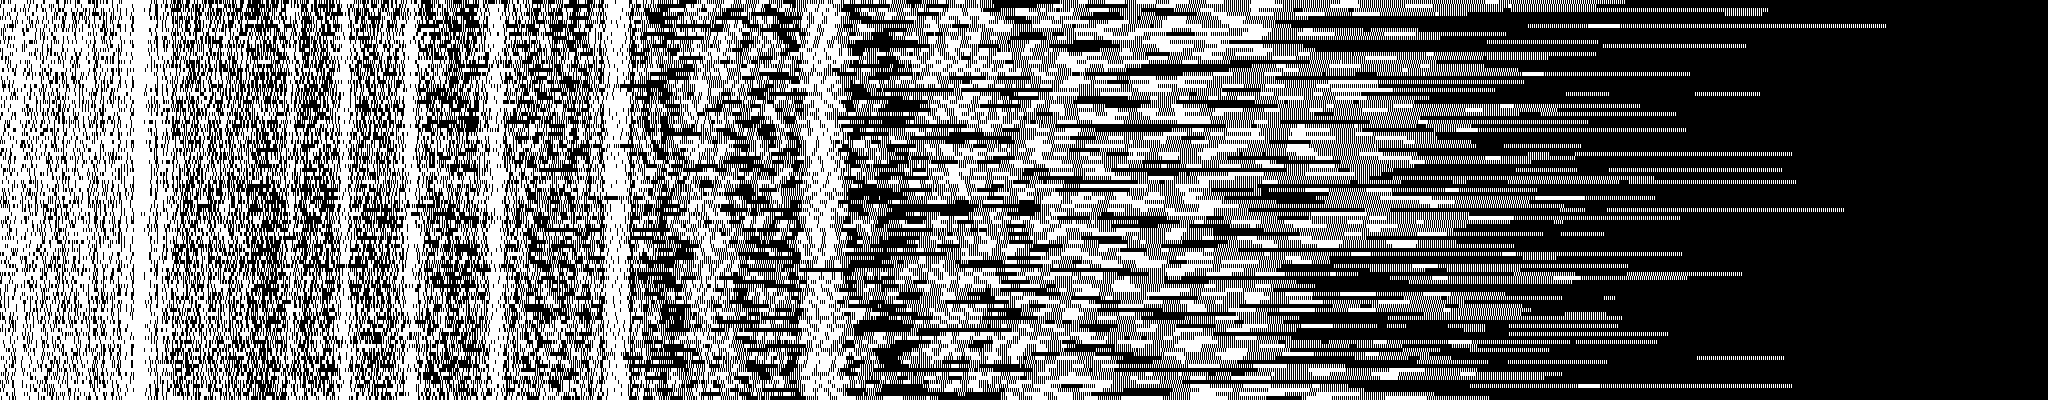

Attempt 0 - Probe's Weights (reg='l2', threshold=0.001)


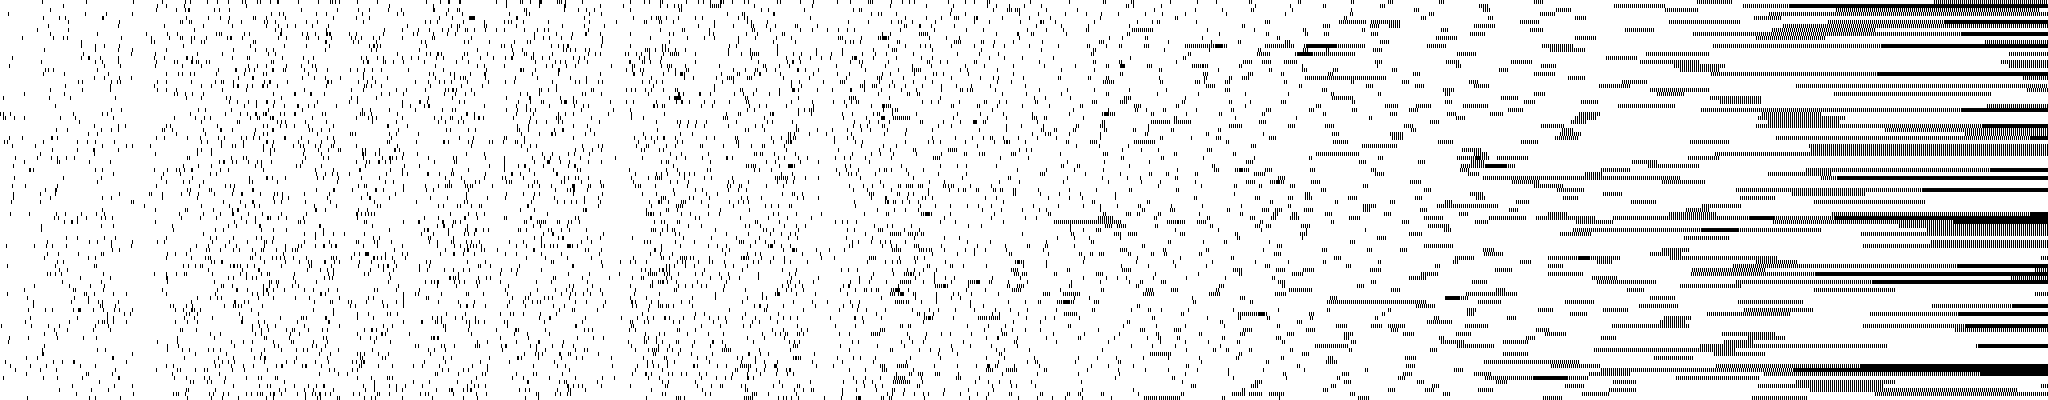

Attempt 1 - Probe's Weights (reg='l2', threshold=0.001)


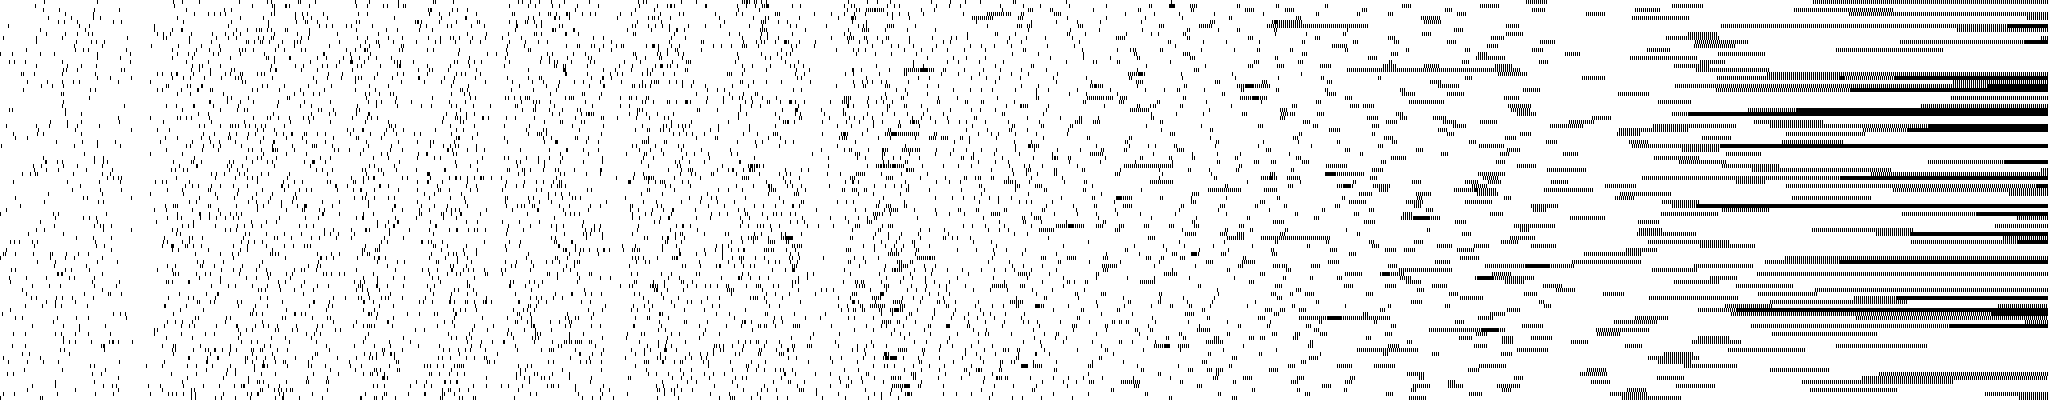

Attempt 2 - Probe's Weights (reg='l2', threshold=0.001)


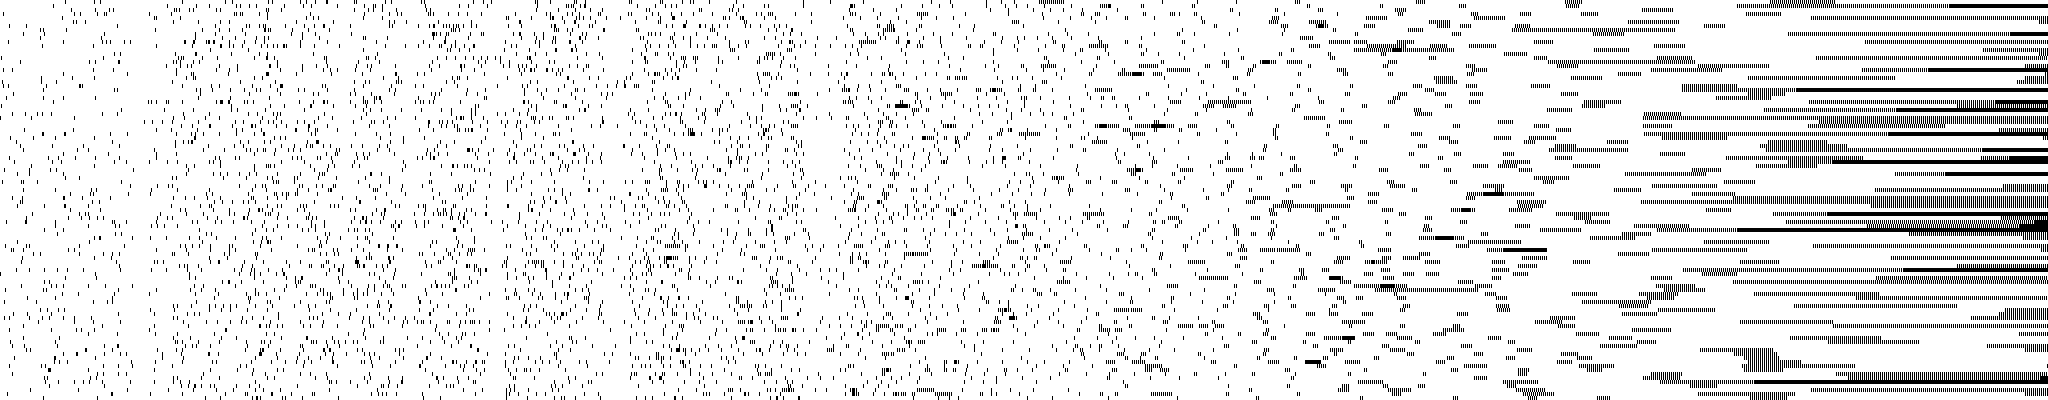

In [86]:
print("x = latent feature", "y = basis features (sine/cosine waves)", "\n")

for reg in probes:
    for threshold in [0.1, 0.01, 0.001]:
        for attempt, probe in enumerate(probes[reg]):
            print(f"Attempt {attempt} - Probe's Weights ({reg=}, {threshold=})", flush=True)
            vis = vis_emb(
                (probe.basis_to_latent.weight.abs() > threshold).float(),
                colorful=False
            )
            display(vis.resize((vis.width, 400), PIL.Image.Resampling.NEAREST))

### Quantitative agreement on most prominent frequencies

In [96]:
# Do probes agree on which frequencies to use?
num_probes = sum(len(v) for v in probes.values())
grid = torch.zeros(num_probes, num_probes)

for i, probe_i in enumerate(itertools.chain(*probes.values())):
    for j, probe_j in enumerate(itertools.chain(*probes.values())):
        coeffs_i = (probe_i.basis_to_latent.weight > 0.1).any(dim=1)
        coeffs_j = (probe_j.basis_to_latent.weight > 0.1).any(dim=1)
        assert coeffs_i.shape == (100,)
        intersection = (coeffs_i & coeffs_j).sum().item()
        union = (coeffs_i | coeffs_j).sum().item()
        jaccard = intersection / union if union > 0 else 0
        grid[i, j] = jaccard


labels = [f"{k}-reg attempt={i}" for k, v in probes.items() for i in range(len(v))]
# show on ticks - (l1-reg attempt 1, ... based on order in probes dict)
plotly.express.imshow(
    grid,
    color_continuous_scale="Blues",
    x = labels,
    y = labels
)


Observations
- L1-reg probes don't agree much with each other about which base frequencees to use even when fitted on the exact same data
- L2-reg probes agree with each other very well on the most prominent frequencies, but each of them uses a almost all frequencies to some extent bacause L2-reg doesn't force the sparsity